# Lab Sheet 4

In [1]:
from header import *

Exercise 1.1

<IPython.core.display.Latex object>

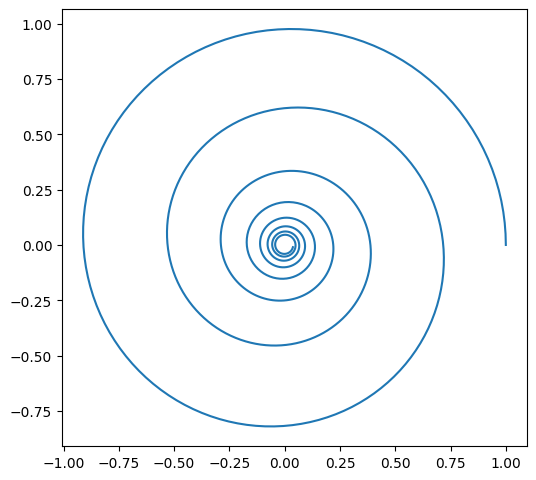

In [3]:
t = sp.symbols('t')
x = sp.cos(10*t)/(1+t*t)
y = sp.sin(10*t)/(1+t*t)
display(Latex("Here is the curve given parametrically by $$(x, y)=(" + sp.latex(x) + "," + sp.latex(y) + ")$$."))
ts = np.linspace(0, 5, 1000)
xys = sp.lambdify(t, [x,y], 'numpy')(ts)
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
ax.plot(xys[0], xys[1])



This starts at $(1,0)$ and moves anticlockwise spiralling in towards the origin.


<IPython.core.display.Latex object>

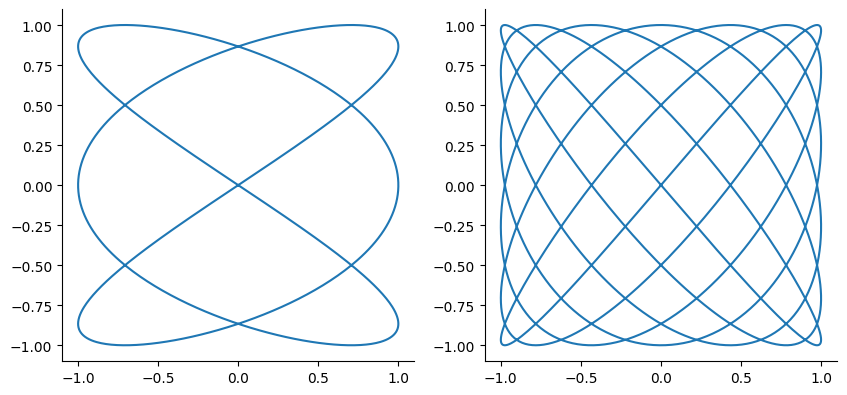

In [14]:
x0 = sp.sin(3*t)
y0 = sp.sin(2*t)
x1 = sp.sin(6*t)
y1 = sp.sin(7*t)
display(Latex("Here are two curves given parametrically by $(x_0, y_0)=(" + sp.latex(x0) + "," + sp.latex(y0) + ")$ and $(x_1, y_1)=(" + sp.latex(x1) + "," + sp.latex(y1) + ")$."))
ts = np.linspace(0, 2*np.pi, 1000)
xys0 = sp.lambdify(t, [x0,y0], 'numpy')(ts)
xys1 = sp.lambdify(t, [x1,y1], 'numpy')(ts)
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].set_aspect('equal')
fix_axes(ax[0]).plot(xys0[0], xys0[1])
ax[1].set_aspect('equal')
fix_axes(ax[1]).plot(xys1[0], xys1[1])

These are examples of [Lissajous curves](https://en.wikipedia.org/wiki/Lissajous_curve).

<IPython.core.display.Latex object>

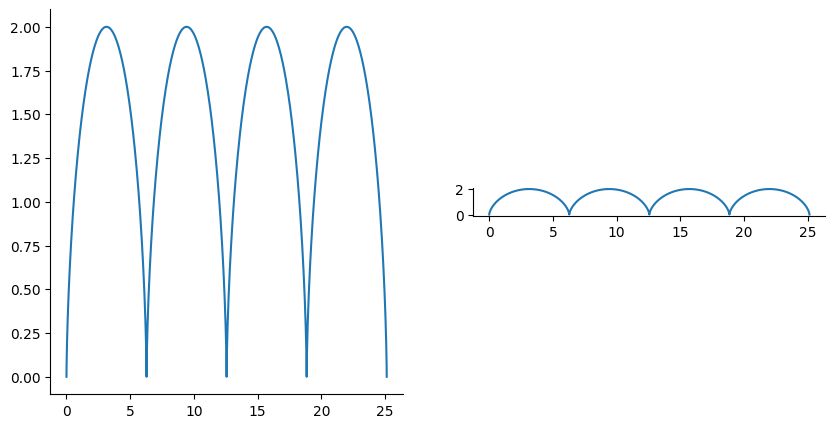

In [18]:
x = t - sp.sin(t)
y = 1 - sp.cos(t)
display(Latex("Here is the curve given parametrically by $$(x, y)=(" + sp.latex(x) + "," + sp.latex(y) + ").$$"))
ts = np.linspace(0, 8*np.pi, 1000)
xys = sp.lambdify(t, [x,y], 'numpy')(ts)
fig, ax = plt.subplots(1,2, figsize=(10,5))
fix_axes(ax[0]).plot(xys[0], xys[1])
ax[1].set_aspect('equal')
fix_axes(ax[1]).plot(xys[0], xys[1])
None


This is a [cycloid curve](https://en.wikipedia.org/wiki/Cycloid), which is traced out by a point on the edge of a wheel as the wheel rolls along the ground.  The right hand picture is more informative because the scales on the $x$ and $y$ axes are the same, which is not the case for the left hand picture.

<IPython.core.display.Latex object>

<Axes: >

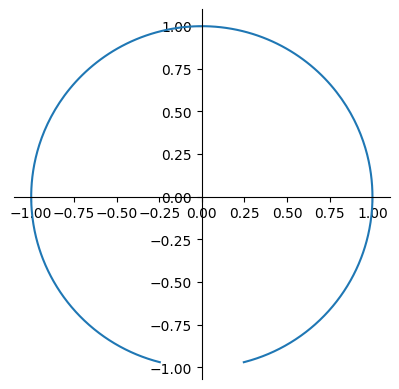

In [20]:
x = 2 * t/(1+t*t)
y = (1-t*t)/(1+t*t)
display(Latex("Here is the curve given parametrically by $$(x, y)=(" + sp.latex(x) + "," + sp.latex(y) + ").$$"))
ts = np.linspace(-8, 8, 1000)
xys = sp.lambdify(t, [x,y], 'numpy')(ts)
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(xys[0], xys[1])
fix_axes(ax)

This is (most of) a circle of radius one, centred at the origin.  To see algebraically that the point $\left(\frac{2t}{1+t^2},\frac{1-t^2}{1+t^2}\right)$ lies on the circle, we must show that $\left(\frac{2t}{1+t^2}\right)^2+\left(\frac{1-t^2}{1+t^2}\right)^2=1$.  We can do this using `sympy` as follows.


In [29]:
del t
t = sp.symbols('t')
x = 2 * t/(1 + t*t)
y = (1 - t*t)/(1 + t*t)
sp.simplify(x*x + y*y)

1

In [30]:
del t, x, y

Exercise 1.2

In [21]:
t = sp.symbols('t')
x = 4*t**2-1
y = 8*t**3-8*t

<IPython.core.display.Latex object>

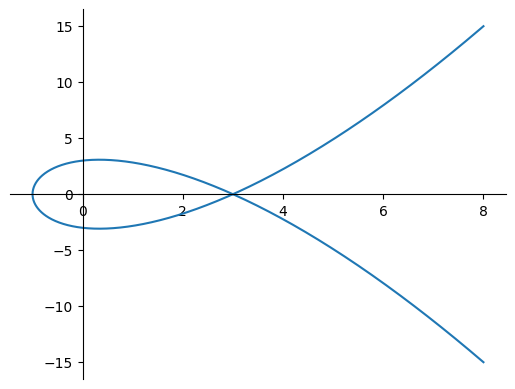

In [22]:
display(Latex("Here is the curve given parametrically by $(x, y)=(" + sp.latex(x) + "," + sp.latex(y) + ")$."))
ts = np.linspace(-1.5, 1.5, 1000)
xys = sp.lambdify(t, [x,y], 'numpy')(ts)
plt.plot(xys[0], xys[1])
fix_axes(plt.gca())
None

We can see from the graph that the curve crosses itself at the point where $x=3$ and $y=0$.  We can find the corresponding values of $t$ as follows:

In [23]:
sols = sp.solve([x-3,y])
print(sols)
print([[x.subs(s), y.subs(s)] for s in sols])

[{t: -1}, {t: 1}]
[[3, 0], [3, 0]]


We can also look for places where the curve crosses the $y$-axis, i.e. places where $x=0$.

In [34]:
sols = sp.solve([x])
print(sols)
print([[x.subs(s), y.subs(s)] for s in sols])

[{t: -1/2}, {t: 1/2}]
[[0, 3], [0, -3]]


We conclude that the curve crosses the $y$ axis at the points $[0,-3]$ (when $t=\frac{1}{2}$) and $[0,3]$ (when $t=-\frac{1}{2}$).


We now plot the original curve (dotted, in red) together with the curve $y=(x-3)\sqrt{x+1}$ (for $x\geq -1$) (in blue).

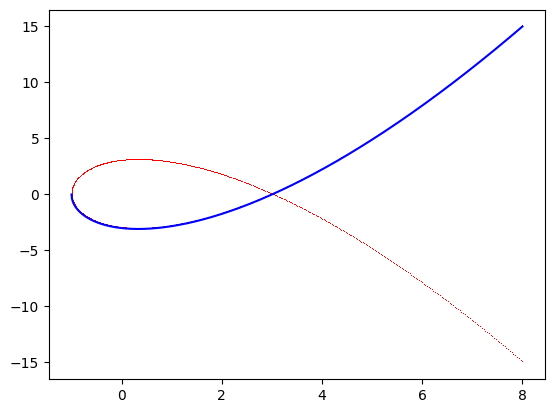

In [24]:
xs = np.linspace(-1, 8, 1000)
ys = (xs - 3) * np.sqrt(xs + 1)
plt.plot(xys[0], xys[1], 'r,')
plt.plot(xs, ys, 'b-')


The two curves fit together, indicating that our functions $x=4t^{2}-1$ and $y=8 t^{3}-8t$ satisfy $y=(x-3) \sqrt{x+1}$.  As the graph of $(x-3) \sqrt{x+1} $ covers only half of the curve, there must be some wrinkle in the story somewhere, and it is not too hard to see that this comes from the sign ambiguity in the square root.  The right thing to check is the equation obtained by squaring, which says that $y^{2}=(x-3)^{2} (x+1)$.  Sympy tells us that this is indeed correct:

In [25]:
sp.simplify(y**2 - (x-3)**2*(x+1))

0

In [37]:
del t, x, y, ts, xys, xs, ys

Exercise 2.1

We now plot the curve given by $y^2=x^3-x$.

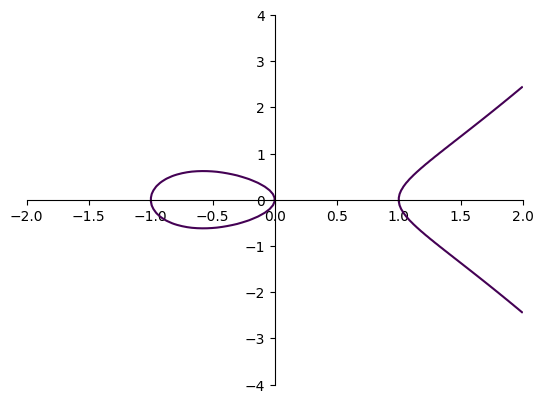

In [27]:
xs, ys = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-4, 4, 100))
zs = ys**2 - xs ** 3 + xs
fig, ax = plt.subplots()
ax.contour(xs, ys, zs, levels=[0])
fix_axes(ax)
None

The picture below shows that the topology of the curve $y^{2}=x^{3}-x+a$ changes somewhere between $a=0.3$ and $a=0.4$.

<Axes: >

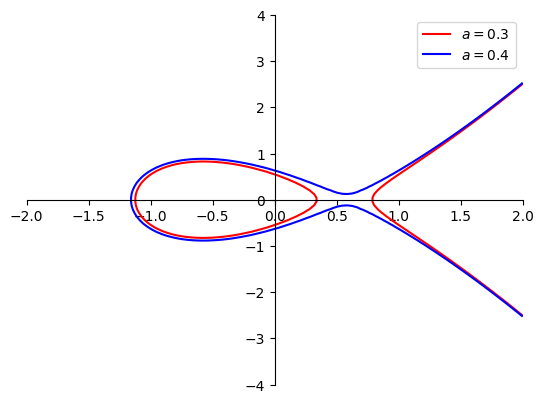

In [46]:
xs, ys = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-4, 4, 100))
zs = ys**2 - xs ** 3 + xs
fig, ax = plt.subplots()
ax.contour(xs, ys, zs, levels=[0.3, 0.4], colors=['red','blue'])
l0 = plt.Line2D([], [], color='red' , label='$a=0.3$')
l1 = plt.Line2D([], [], color='blue', label='$a=0.4$')
ax.legend(handles=[l0,l1])
fix_axes(ax)

In fact the change happens at $a=\frac{2}{3\sqrt{3}}\approx 0.3849$, as shown by the zoomed-in picture below.

<Axes: >

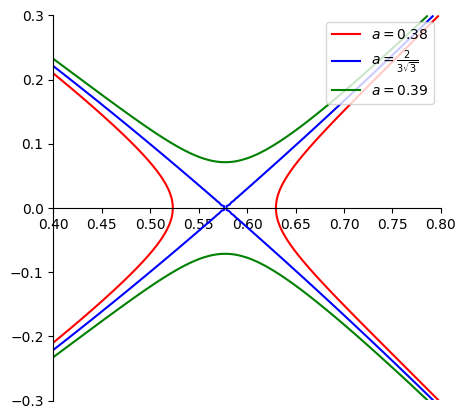

In [47]:
xs, ys = np.meshgrid(np.linspace(0.4, 0.8, 100), np.linspace(-0.3, 0.3, 100))
zs = ys**2 - xs ** 3 + xs
fig, ax = plt.subplots(figsize=(5,5))
ax.contour(xs, ys, zs, levels=[0.38,2/3/np.sqrt(3),0.39],colors=['r','b','g'])
l0 = plt.Line2D([], [], color='red' , label='$a=0.38$')
l1 = plt.Line2D([], [], color='blue', label='$a=\\frac{2}{3\\sqrt{3}}$')
l2 = plt.Line2D([], [], color='green', label='$a=0.39$')
ax.legend(handles=[l0,l1,l2])
fix_axes(ax)

We can derive the critical value of $a$ as follows.  Note that we have $y=\sqrt{g(x)}$ or $y=-\sqrt{g(x)}$, where $g(x)=x^{3}-x+a$.  If $g(x) $ is negative near $x=0.6$ then there is no square root and we have a gap in the graph.  If $g(x) $ is positive near $x=0.6$ then there are two separate square roots and so two disjoint branches of the graph.  The crossover occurs when the graph of $g(x)$ just touches the $x$-axis near $x=0.6$, so we have a repeated root, where $g(x)$ and its derivative both vanish.  The derivative is $3x^{2}-1$, and the
only place near $x=0.6$ where this vanishes is at $x=\frac{1}{\sqrt{3}}$, which means that $g(x)=(\frac{1}{\sqrt{3}})^{3}-\frac{1}{\sqrt{3}}+a$.  We want this to be zero as well, so we must have $a=\frac{1}{\sqrt{3}}-(\frac{1}{\sqrt{3}})^{3}=\frac{2}{3 \sqrt{3}}\approx 0.3849001795$.


Exercise 2.2

We now look at the curve $x^{2}+y^{2}+a(\sin (2\pi x)+\cos (2\pi y))=100$.  When $a=0$, this is just a circle.  When $a=1$, it is a circle with wiggles.  As 
$a$ increases, we get an octagonal curve with squarish wiggles, with rows of bubbles running parallel to the curve, with the more distant rows being smaller.


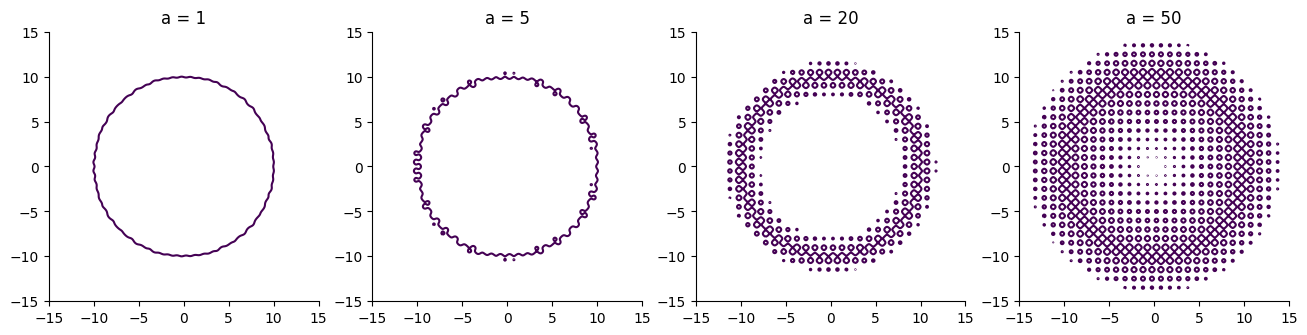

In [50]:
xs, ys = np.meshgrid(np.linspace(-15, 15, 400), np.linspace(-15, 15, 400))
rs = xs**2 + ys**2
ss = np.sin(2*np.pi*xs) + np.cos(2*np.pi*ys)
fig, ax = plt.subplots(1,4,figsize=(16,4))
for i, a in enumerate([1, 5, 20, 50]):
    fix_axes(ax[i])
    ax[i].set_aspect('equal')
    ax[i].set_xlim(-15,15)
    ax[i].set_ylim(-15,15)
    ax[i].contour(xs, ys, rs + a * ss, levels=[100])
    ax[i].title.set_text(f'a = {a}')

Exercise 3.1

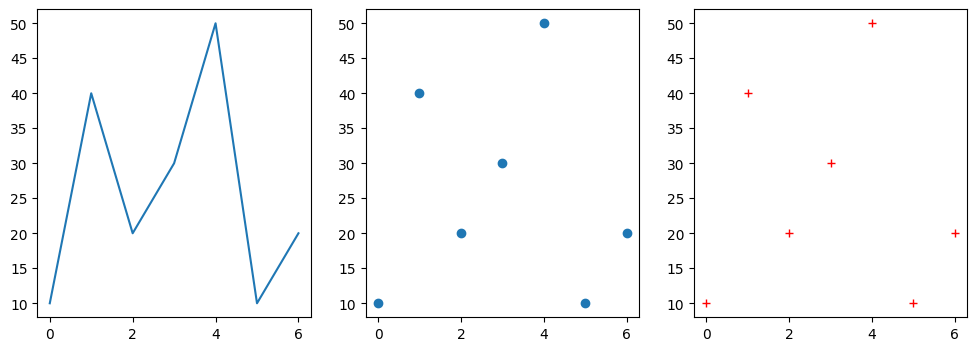

In [41]:
fig, ax = plt.subplots(1,3,figsize=(12,4))
vals = [10,40,20,30,50,10,20]
ax[0].plot(vals)
ax[1].plot(vals,'o')
ax[2].plot(vals,'r+')


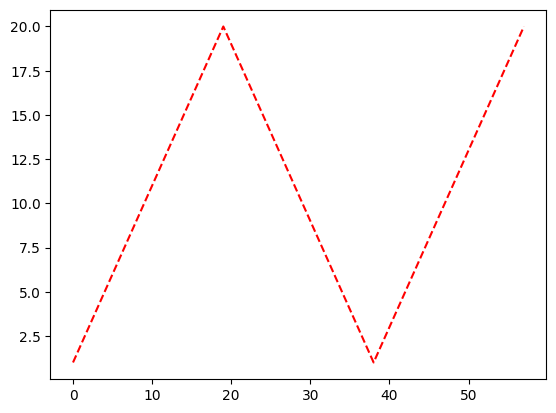

In [42]:
plt.plot([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
          19,18,17,16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,
          2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],'r--')

Exercise 3.2

Let $p_n$ be the $n$ th prime (starting with $p_1=2$, $p_2=3$ and so on), and put $q_n=n(\log(\log(n))+\log(n)-1)$ (for $n>1$).  It is known that $p_n$ is approximately equal to $q_n$ when $n$ is large.  Note, however, that $q_1$ is undefined, because $\log(1)=0$ and so $\log(\log(1))$ is not meaningful.  Here we plot $p_2,\dotsc,p_{100}$ alongside $q_2,\dotsc,q_{100}$. sympy does not give us a direct way to ask for the first 100 primes, but we can ask for all primes less than 542, which turns out to be the same.

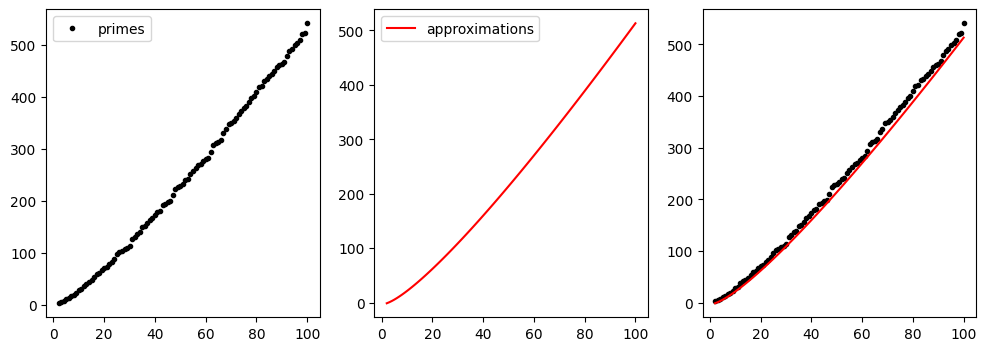

In [6]:
ps = list(sp.primerange(542))[1:] # Use [1:] to omit p_1 = 2
ns = np.arange(2,len(ps)+2)
qs = ns * (np.log(np.log(ns)) + np.log(ns)-1)
fig, ax = plt.subplots(1,3,figsize=(12,4))
ax[0].plot(ns, ps, 'k.', label='primes')
ax[0].legend()
ax[1].plot(ns, qs, 'r-', label='approximations')
ax[1].legend()
ax[2].plot(ns, ps, 'k.')
ax[2].plot(ns, qs, 'r-')


Exercise 3.3

Stirling's formula says that $n!\approx\sqrt{2\pi n}(n/e)^n$.  Here we plot some graphs to visualise this.

In [44]:
n = 20
N = sp.factorial(n)
print(f"{n}! = {N} = {float(N):.6e}")

20! = 2432902008176640000 = 2.432902e+18


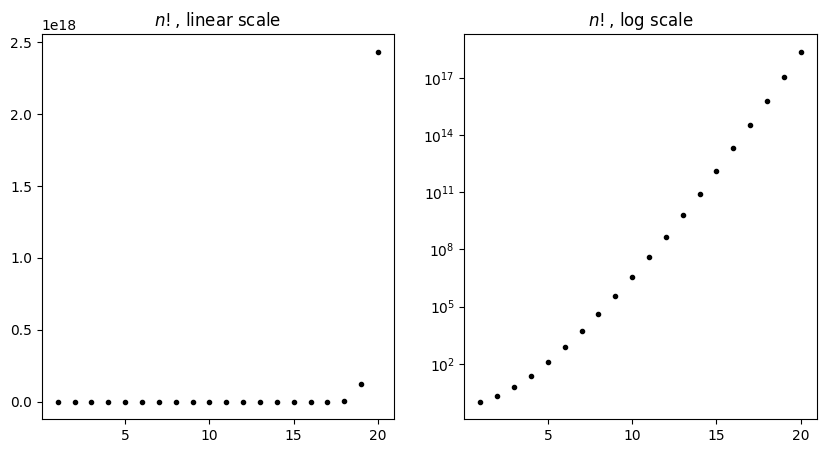

In [45]:
nn = np.arange(1, n+1)
ff = [float(sp.factorial(i)) for i in nn]
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].plot(nn, ff, 'k.')
ax[0].title.set_text('$n!$, linear scale')
ax[1].plot(nn, ff, 'k.')
ax[1].set_yscale('log')
ax[1].title.set_text('$n!$, log scale')


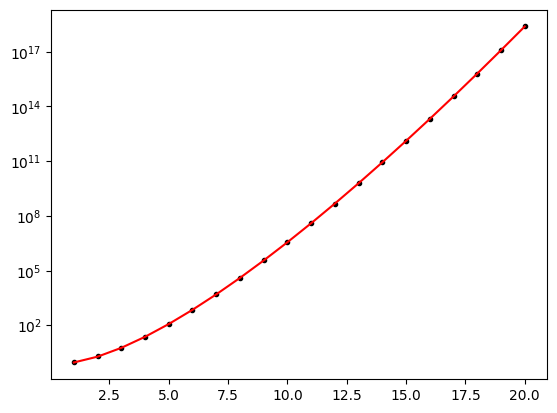

In [46]:
def stirling(n):
    return np.sqrt(2*np.pi*n) * (n/np.e)**n

ss = stirling(nn)
plt.plot(nn, ff, 'k.')
plt.plot(nn, ss, 'r-')
plt.yscale('log')